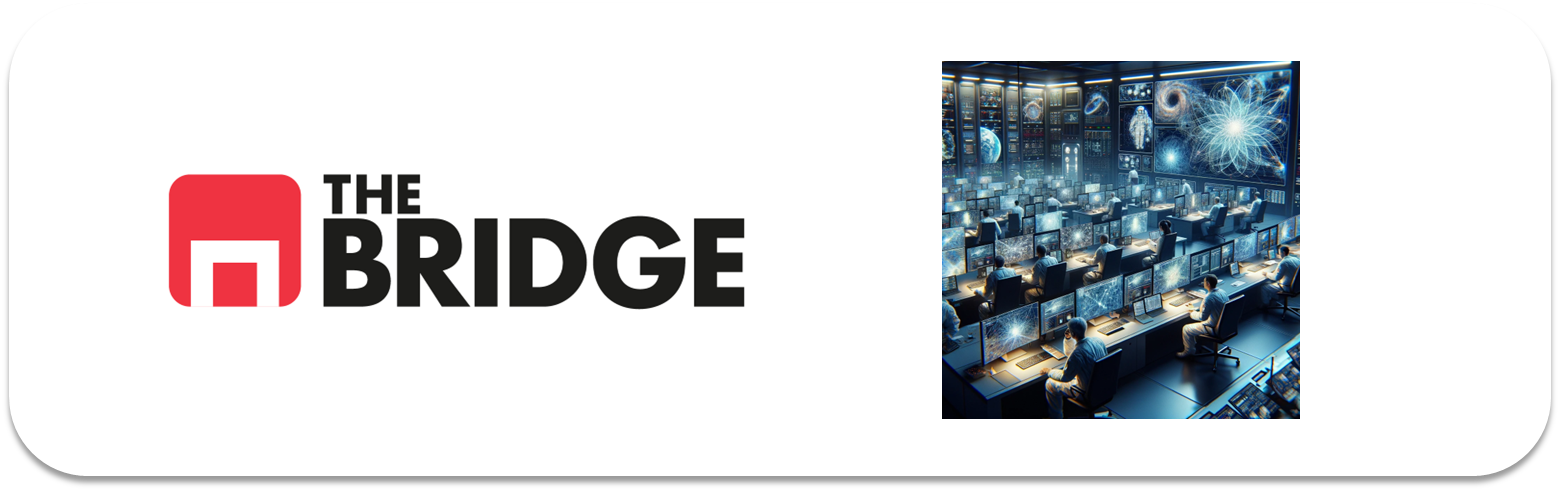

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
!pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB 640.0 kB/s eta 0:01:09
   ---------------------------------------- 0.3/44.0 MB 3.2 MB/s eta 0:00:14
    --------------------------------------- 0.7/44.0 MB 6.2 MB/s eta 0:00:07
   - -------------------------------------- 1.3/44.0 MB 8.1 MB/s eta 0:00:06
   - -------------------------------------- 1.9/44.0 MB 10.1 MB/s eta 0:00:05
   -- ------------------------------------- 2.6/44.0 MB 11.2 MB/s eta 0:00:04
   --- ------------------------------------ 3.6/44.0 MB 13.4 MB/s eta 0:00:04
   ---- ----------------------------------- 4.6/44.0 MB 15.5 MB/s eta 0:00:03
   ----- ---------------------------------- 5.6/44.0 MB 16.3 MB/s eta 0:00:03
   ------ --------------------------------- 6.6/44.0 MB 17.6 MB/s eta 0:00:03
   ------- -------------------------------- 7.7/44.0 MB 18.3 MB/s eta 0:00:02
   -


[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2  
import os
import bootcampviztools as bt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from time import time
import seaborn as sns


### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



In [8]:
def read_data(directorios, reshape_dim = (32,32)):
    X=[]
    y=[]
    
    mapa_imagen_fichero = []
    directorios = directorios if isinstance(directorios, list) else [directorio] if isinstance(directorio, str) else []
    for directorio in directorios:
        for file in os.listdir(directorio):
            image = cv2.imread('/'.join([directorio, file]))
            image = cv2.resize(image, reshape_dim)
            X.append(image)
            y.append(file.split('.')[0])
            mapa_imagen_fichero.append(file)
    return np.array(X), np.array(y), mapa_imagen_fichero

In [9]:
PATH_DATA = "./data/"
directorios = [f"{PATH_DATA}github_train_{i}" for i in range(0,4)]
directorios

['./data/github_train_0',
 './data/github_train_1',
 './data/github_train_2',
 './data/github_train_3']

In [10]:
X_train, y_train, train_map = read_data(directorios)

In [11]:
X_train

array([[[[ 64, 100, 126],
         [ 53,  92, 118],
         [ 63, 104, 129],
         ...,
         [ 45,  69,  88],
         [ 25,  40,  98],
         [ 50,  72, 121]],

        [[ 61,  92, 113],
         [ 68, 102, 122],
         [ 75, 111, 131],
         ...,
         [ 57,  75, 131],
         [ 23,  53,  99],
         [ 22,  42,  99]],

        [[ 64,  96, 120],
         [ 74, 110, 133],
         [ 63, 103, 126],
         ...,
         [ 12,  25,  79],
         [  2,  12,  50],
         [  6,  32,  79]],

        ...,

        [[ 10,  15,  15],
         [ 69,  79,  82],
         [ 51,  67,  73],
         ...,
         [ 69,  95, 103],
         [ 53,  75,  83],
         [ 60,  92,  98]],

        [[ 88,  99,  97],
         [ 49,  63,  66],
         [ 51,  69,  80],
         ...,
         [ 39,  61,  70],
         [ 61,  79,  88],
         [ 68,  92, 100]],

        [[ 44,  55,  63],
         [ 39,  55,  64],
         [ 50,  71,  82],
         ...,
         [ 46,  72,  86],
        

In [12]:
y_train

array(['cat', 'cat', 'cat', ..., 'dog', 'dog', 'dog'],
      shape=(4000,), dtype='<U3')

In [13]:
directorio_test = f"{PATH_DATA}github_test"
X_test, y_test, test_map = read_data([directorio_test])

In [14]:
y_test

array(['cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat',
       'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat',
       'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat',
       'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat',
       'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat',
       'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat',
       'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat',
       'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat',
       'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat',
       'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat',
       'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat',
       'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat',
       'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat',
       'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat',
       'cat', 'cat',

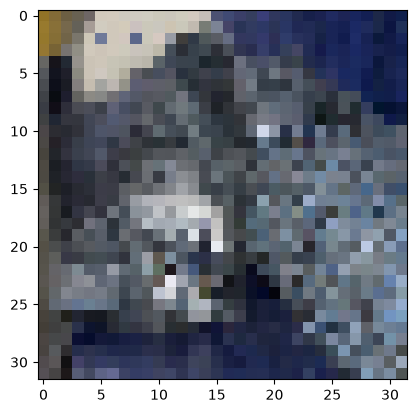

In [16]:
plt.imshow(X_test[3])

In [17]:
y_test[3]

np.str_('cat')

In [18]:
def show_images_batch (pets, names=[], n_cols=5, size_scale=2):
    n_rows = ((len(pets)-1) // n_cols + 1)
    plt.figure(figsize=(n_cols*size_scale, n_rows * 1.1 * size_scale))
    for i, pet in enumerate(pets):
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(pet, cmap='Greys')
        plt.axis('off')
        if len(names):
            plt.title(names[i])
  

In [19]:
def show_images_files(pets, names = [], n_cols=5, size_scale=2, train=True, indice=0):
    n_rows = ((len(pets)-1) // n_cols + 1)
    plt.figure(figsize=(n_cols*size_scale, n_rows * 1.1 * size_scale))
    for i, filepet in enumerate(pets):
        plt.subplot(n_rows, n_cols, i+1)
        if train:
            pet = cv2.imread(PATH_DATA + f"github_train_{indice}/ " + filepet)
        else:
            pet = cv2.imread(PATH_DATA + f"github_test/ " + filepet)
        plt.imshow(pet, cmap='Greys')
        plt.axis('off')
        if len(names):
                    plt.title(names[i])
             

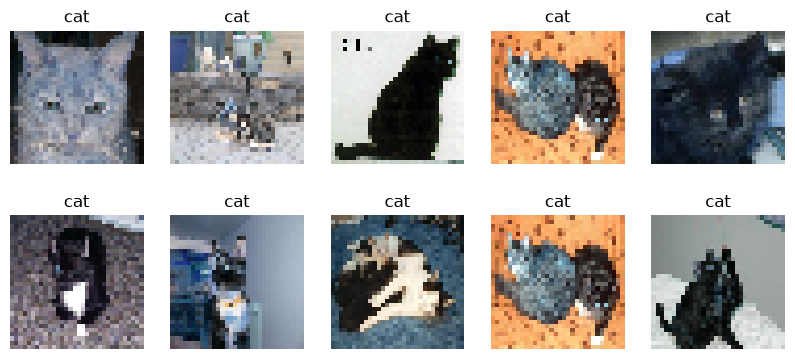

In [21]:
indices = np.random.randint(100,300,10)
show_images_batch(X_train[indices], names = y_train[indices])

TypeError: Image data of dtype object cannot be converted to float

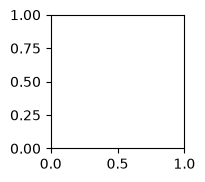

In [ ]:
show_images_files([train_map[i] for i in indices], names = y_train[indices])

In [ ]:
#MINI EDA

<Axes: title={'center': 'Distribución de clases en el dataset de entrenamiento'}>

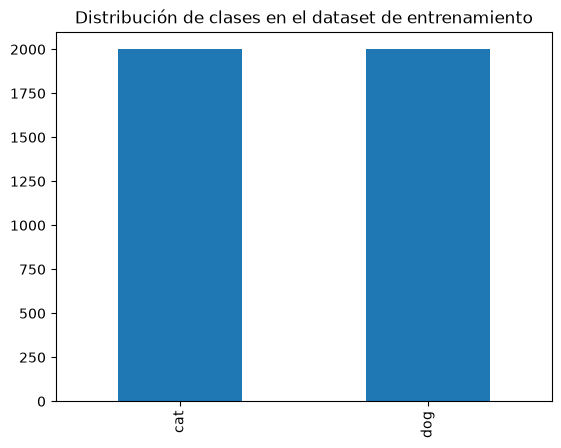

In [27]:
pd.Series(y_train).value_counts().plot(kind='bar', title='Distribución de clases en el dataset de entrenamiento')

In [28]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [29]:
def aplana_escala_grises(array_in, grises = True):
    def convertir_a_escala_de_grises(imagen_color):
        coeficientes = np.array([0.2989, 0.5870, 0.1140])
        imagen_gris = np.dot(imagen_color[...,:3], coeficientes)
        return imagen_gris
    
    if array_in.shape[-1] == 3 and grises:
        array_in = np.array([convertir_a_escala_de_grises(imagen) for imagen in array_in])
    return array_in.reshape(array_in.shape[0], -1)    

In [31]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import cross_val_score, train_test_split

In [32]:
X_train_rf = aplana_escala_grises(X_train)
len(X_train_rf[0])

1024

In [30]:
from sklearn.utils import shuffle

In [33]:
X_train_rf_shuffled, y_train_shuffled = shuffle(X_train_rf, y_train, random_state=42)

In [36]:
y_train_shuffled.tolist()

['cat',
 'dog',
 'cat',
 'dog',
 'dog',
 'cat',
 'cat',
 'cat',
 'cat',
 'cat',
 'dog',
 'dog',
 'cat',
 'cat',
 'dog',
 'dog',
 'cat',
 'cat',
 'cat',
 'cat',
 'cat',
 'cat',
 'dog',
 'cat',
 'dog',
 'cat',
 'dog',
 'dog',
 'dog',
 'cat',
 'dog',
 'cat',
 'dog',
 'dog',
 'dog',
 'cat',
 'cat',
 'cat',
 'dog',
 'dog',
 'dog',
 'cat',
 'dog',
 'cat',
 'dog',
 'dog',
 'cat',
 'cat',
 'cat',
 'dog',
 'cat',
 'dog',
 'cat',
 'cat',
 'cat',
 'cat',
 'dog',
 'cat',
 'dog',
 'dog',
 'dog',
 'cat',
 'dog',
 'dog',
 'dog',
 'cat',
 'dog',
 'cat',
 'cat',
 'cat',
 'cat',
 'dog',
 'dog',
 'cat',
 'cat',
 'dog',
 'dog',
 'cat',
 'cat',
 'cat',
 'dog',
 'cat',
 'cat',
 'cat',
 'dog',
 'cat',
 'dog',
 'cat',
 'dog',
 'dog',
 'cat',
 'dog',
 'dog',
 'cat',
 'cat',
 'cat',
 'cat',
 'dog',
 'cat',
 'cat',
 'cat',
 'dog',
 'dog',
 'cat',
 'dog',
 'cat',
 'cat',
 'cat',
 'dog',
 'dog',
 'dog',
 'cat',
 'dog',
 'cat',
 'cat',
 'dog',
 'cat',
 'cat',
 'cat',
 'dog',
 'cat',
 'dog',
 'cat',
 'dog',
 'dog',


In [37]:
rf_clf = RandomForestClassifier()
np.mean(cross_val_score(rf_clf, X_train_rf_shuffled, y_train_shuffled, cv=5, scoring='accuracy'))

np.float64(0.6125)

In [38]:
layers = [
    keras.Input(shape=(32, 32, 3)),
    keras.layers.Conv2D(64,(3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    keras.layers.Dropout(0.25),
    
    keras.layers.Conv2D(128,(3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    keras.layers.Dropout(0.25),
    
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
]

model = keras.Sequential(layers)

In [39]:
optimizer = keras.optimizers.Adam()

In [ ]:
metrics = ['accuracy']
loss = 'binary_crossentropy'

In [ ]:
batch_size = 32
num_epochs = 100
early_stopping = keras.callbacks.EarlyStopping(patience=10)

In [42]:
model.compile(optimizer=optimizer, 
              loss=loss, metrics=metrics)

In [43]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,270,977 (16.29 MB)

 Trainable params: 4,270,977 (16.29 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
y_train[np.array([1,2,3560])]

array(['cat', 'cat', 'dog'], dtype='<U3')

In [45]:
y_train_num = np.array([0 if y == 'cat' else 1 for y in y_train])

In [46]:
t_zero = time()

In [47]:
history = model.fit(X_train, y_train_num, batch_size=batch_size,
                    epochs=num_epochs, validation_split=0.2, callbacks=[early_stopping])



Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 110ms/step - accuracy: 0.6069 - loss: 0.6912 - val_accuracy: 0.0000e+00 - val_loss: 0.8704
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.6266 - loss: 0.6477 - val_accuracy: 0.0050 - val_loss: 0.9647
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.6772 - loss: 0.6096 - val_accuracy: 0.1350 - val_loss: 0.9352
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 0.6909 - loss: 0.5830 - val_accuracy: 0.2488 - val_loss: 1.0394
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.7191 - loss: 0.5551 - val_accuracy: 0.4888 - val_loss: 0.8304
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 0.7369 - loss: 0.5333 - val_accuracy: 0.5350 - val_loss: 0.7575
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.7497 - loss: 0.5090 - val_accuracy: 0.6137 - val_loss: 0.6483
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.7559

In [48]:
df = pd.DataFrame(history.history)

<Axes: title={'center': 'Loss'}>

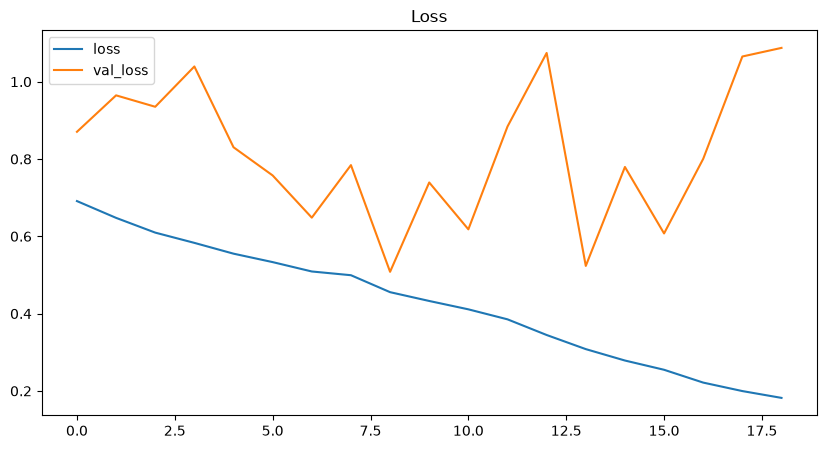

In [49]:
df[['loss', 'val_loss']].plot(title='Loss', figsize=(10,5))

In [2]:
from sklearn.preprocessing import LabelEncoder

In [4]:
import numpy as np

In [ ]:
y_pred = ["dog" if predictions[0] > 0.5 else "cat" for predictions in model.predict(X_test)]
print(classification_report(y_test, y_pred))

NameError: name 'model' is not defined